# UWAGA - zweryfikować, co z teorii chcemy zostawić, co skrócić, co wyrzucić itp...

# Algorytm najszybszego spadku dla regresji wielomianowej

Celem projektu jest implementacja algorytmu najszybszego spadku dla problemu regresji wielomianowej jednej zmiennej. Zakładamy, że dany jest zbiór obserwacji składający się z par:

$$
(x_i, y_i), \quad i = 1, 2, \ldots, m
$$

gdzie:

- $x_i$ oznacza wartość cechy wejściowej,
- $y_i$ oznacza odpowiadającą jej wartość zmiennej objaśnianej,
- $m$ oznacza liczbę obserwacji w zbiorze danych.

Celem jest znalezienie wielomianu możliwie dobrze opisującego zależność $y$ od $x$.

Model regresji wielomianowej stopnia $n$ zapisujemy w postaci:

$$
\hat{y} = \theta_0 + \theta_1 x + \theta_2 x^2 + \ldots + \theta_n x^n
$$

gdzie:

- $\hat{y}$ oznacza wartość przewidywaną przez model,
- $\theta_0, \theta_1, \ldots, \theta_n$ są parametrami modelu,
- $n$ jest stopniem wielomianu.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("data/linear.csv")

x = data["x"].values
y = data["y"].values

print(data.head())
print(x.shape, y.shape)

            x           y
0 -100.000000 -199.000000
1  -99.933311 -198.866622
2  -99.866622 -198.733244
3  -99.799933 -198.599867
4  -99.733244 -198.466489
(3000,) (3000,)


## Normalizacja zmiennej wejściowej

W regresji wielomianowej wartości kolejnych potęg zmiennej $x$ mogą bardzo szybko rosnąć. Przykładowo, jeśli $x = 100$, to:

$$
x^2 = 10000, \quad x^3 = 1000000
$$

Tak duże wartości mogą prowadzić do problemów numerycznych oraz utrudniać działanie algorytmu gradientowego. Z tego powodu przed utworzeniem cech wielomianowych normalizujemy zmienną wejściową.

Stosujemy standaryzację:

$$
z_i = \frac{x_i - \mu}{\sigma}
$$

gdzie:

- $z_i$ to znormalizowana wartość obserwacji,
- $x_i$ to pierwotna wartość cechy,
- $\mu$ to średnia wartości $x$,
- $\sigma$ to odchylenie standardowe wartości $x$.

Po normalizacji wartości cechy są przesunięte względem średniej i przeskalowane względem odchylenia standardowego. Dzięki temu algorytm optymalizacji działa stabilniej.

In [3]:
def normalize_feature(x):
    """
    Normalizuje cechę x.

    Zwraca:
    - x_normalized: znormalizowane wartości x
    - mean: średnia x
    - std: odchylenie standardowe x
    """
    mean = np.mean(x)
    std = np.std(x)

    if std == 0:
        raise ValueError("Odchylenie standardowe x wynosi 0. Nie można wykonać normalizacji.")

    x_normalized = (x - mean) / std
    return x_normalized, mean, std

## Konstrukcja cech wielomianowych

Aby zastosować regresję wielomianową, przekształcamy jedną zmienną wejściową $x$ w zestaw jej kolejnych potęg.

Dla wielomianu stopnia $n$ tworzymy wektor cech:

$$
\phi(x_i) =
\begin{bmatrix}
1 & x_i & x_i^2 & \ldots & x_i^n
\end{bmatrix}
$$

Dla wszystkich obserwacji otrzymujemy macierz cech:

$$
X =
\begin{bmatrix}
1 & x_1 & x_1^2 & \ldots & x_1^n \\
1 & x_2 & x_2^2 & \ldots & x_2^n \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
1 & x_m & x_m^2 & \ldots & x_m^n
\end{bmatrix}
$$

Pierwsza kolumna składa się z jedynek, ponieważ odpowiada parametrowi wolnemu $\theta_0$.

W zapisie macierzowym model można wtedy przedstawić jako:

$$
\hat{y} = X \theta
$$

gdzie:

- $X$ to macierz cech wielomianowych,
- $\theta$ to wektor parametrów modelu,
- $\hat{y}$ to wektor predykcji.

In [4]:
def create_polynomial_features(x, degree):
    """
    Tworzy macierz cech dla regresji wielomianowej.

    Parametry:
    - x: wektor wartości cechy wejściowej
    - degree: stopień wielomianu

    Zwraca:
    - X: macierz cech wielomianowych
    """
    if degree < 0:
        raise ValueError("Stopień wielomianu musi być nieujemny.")

    x = np.asarray(x).reshape(-1, 1)
    X = np.ones((x.shape[0], degree + 1))

    for power in range(1, degree + 1):
        X[:, power] = x[:, 0] ** power

    return X

## Funkcja predykcji

Dla zadanych parametrów modelu $\theta$ predykcja polega na obliczeniu wartości wielomianu dla każdej obserwacji.

Model ma postać:

$$
\hat{y}_i = \theta_0 + \theta_1 x_i + \theta_2 x_i^2 + \ldots + \theta_n x_i^n
$$

W zapisie macierzowym dla całego zbioru danych zapisujemy to jako:

$$
\hat{y} = X\theta
$$

gdzie:

- $\hat{y}$ jest wektorem wartości przewidywanych,
- $X$ jest macierzą cech,
- $\theta$ jest wektorem parametrów.

Taki zapis jest wygodny obliczeniowo, ponieważ pozwala wykonać predykcję dla wszystkich punktów danych jednocześnie.

In [5]:
def predict(X, theta):
    """
    Oblicza predykcje modelu regresji wielomianowej.

    Parametry:
    - X: macierz cech
    - theta: wektor parametrów modelu

    Zwraca:
    - y_pred: przewidywane wartości y
    """
    return X @ theta

## Kwadratowa funkcja straty

Aby ocenić jakość dopasowania modelu, wykorzystujemy kwadratową funkcję straty. Mierzy ona średni błąd pomiędzy wartościami rzeczywistymi $y_i$ a wartościami przewidywanymi $\hat{y}_i$.

Funkcja straty ma postać:

$$
J(\theta) = \frac{1}{2m} \sum_{i=1}^{m} (\hat{y}_i - y_i)^2
$$

Ponieważ:

$$
\hat{y} = X\theta
$$

możemy zapisać funkcję straty również jako:

$$
J(\theta) = \frac{1}{2m} \sum_{i=1}^{m} ((X\theta)_i - y_i)^2
$$

albo w formie wektorowej:

$$
J(\theta) = \frac{1}{2m} \|X\theta - y\|^2
$$

gdzie:

- $J(\theta)$ oznacza wartość funkcji straty,
- $m$ oznacza liczbę obserwacji,
- $X\theta$ jest wektorem predykcji,
- $y$ jest wektorem wartości rzeczywistych.

Czynnik $\frac{1}{2}$ nie zmienia położenia minimum funkcji, ale upraszcza wzór na gradient.

In [6]:
def compute_loss(X, y, theta):
    """
    Oblicza wartość kwadratowej funkcji straty.

    Parametry:
    - X: macierz cech
    - y: rzeczywiste wartości
    - theta: wektor parametrów modelu

    Zwraca:
    - loss: wartość funkcji straty
    """
    m = len(y)
    y_pred = predict(X, theta)
    error = y_pred - y

    loss = (1 / (2 * m)) * np.sum(error ** 2)
    return loss

## Gradient funkcji straty

Aby minimalizować funkcję straty, potrzebujemy informacji o tym, w którym kierunku funkcja rośnie najszybciej. Informację tę dostarcza gradient.

Dla funkcji straty:

$$
J(\theta) = \frac{1}{2m} \|X\theta - y\|^2
$$

gradient względem parametrów $\theta$ ma postać:

$$
\nabla J(\theta) = \frac{1}{m} X^T (X\theta - y)
$$

gdzie:

- $\nabla J(\theta)$ oznacza gradient funkcji straty,
- $X^T$ oznacza transpozycję macierzy cech,
- $X\theta - y$ jest wektorem błędów predykcji.

Gradient wskazuje kierunek największego wzrostu funkcji. Aby zmniejszać wartość funkcji straty, należy poruszać się w kierunku przeciwnym do gradientu.

In [7]:
def compute_gradient(X, y, theta):
    """
    Oblicza gradient funkcji straty względem parametrów theta.

    Parametry:
    - X: macierz cech
    - y: rzeczywiste wartości
    - theta: wektor parametrów modelu

    Zwraca:
    - gradient: wektor gradientu
    """
    m = len(y)
    y_pred = predict(X, theta)
    error = y_pred - y

    gradient = (1 / m) * (X.T @ error)
    return gradient

## Algorytm najszybszego spadku

Algorytm najszybszego spadku jest metodą iteracyjną służącą do minimalizacji funkcji. W każdej iteracji aktualizujemy parametry modelu, przesuwając je w kierunku przeciwnym do gradientu funkcji straty.

Aktualizacja parametrów ma postać:

$$
\theta^{(k+1)} = \theta^{(k)} - \alpha \nabla J(\theta^{(k)})
$$

gdzie:

- $\theta^{(k)}$ oznacza wektor parametrów w $k$-tej iteracji,
- $\theta^{(k+1)}$ oznacza wektor parametrów po aktualizacji,
- $\alpha$ jest współczynnikiem uczenia,
- $\nabla J(\theta^{(k)})$ jest gradientem funkcji straty w aktualnym punkcie.

Współczynnik uczenia $\alpha$ decyduje o długości kroku wykonywanego w kierunku przeciwnym do gradientu. Zbyt duża wartość może spowodować niestabilność algorytmu, natomiast zbyt mała może znacząco spowolnić uczenie.

W projekcie zapisujemy również wartości funkcji straty w kolejnych iteracjach. Pozwala to później przedstawić proces uczenia na wykresie i sprawdzić, czy algorytm rzeczywiście zmniejsza wartość błędu.

In [8]:
def gradient_descent(X, y, learning_rate=0.01, iterations=1000, tolerance=1e-8):
    """
    Implementuje algorytm najszybszego spadku dla regresji wielomianowej.

    Parametry:
    - X: macierz cech
    - y: rzeczywiste wartości
    - learning_rate: współczynnik uczenia
    - iterations: maksymalna liczba iteracji
    - tolerance: próg zatrzymania na podstawie zmiany funkcji straty

    Zwraca:
    - theta: oszacowany wektor parametrów
    - loss_history: historia wartości funkcji straty
    """
    n_features = X.shape[1]
    theta = np.zeros(n_features)

    loss_history = []

    for i in range(iterations):
        gradient = compute_gradient(X, y, theta)
        theta = theta - learning_rate * gradient

        loss = compute_loss(X, y, theta)
        loss_history.append(loss)

        if i > 0 and abs(loss_history[-2] - loss_history[-1]) < tolerance:
            print(f"Zatrzymano po {i + 1} iteracjach.")
            break

    return theta, loss_history

## Dopasowanie modelu do danych

Po zdefiniowaniu funkcji pomocniczych możemy przeprowadzić pełny proces uczenia modelu.

Kolejne kroki są następujące:

1. wczytanie danych,
2. normalizacja zmiennej wejściowej,
3. utworzenie cech wielomianowych dla wybranego stopnia wielomianu,
4. inicjalizacja parametrów modelu,
5. minimalizacja funkcji straty za pomocą algorytmu najszybszego spadku,
6. zwrócenie oszacowanych parametrów oraz historii wartości funkcji straty.

Dzięki parametrowi `degree` można łatwo zmieniać stopień wielomianu i obserwować, jak wpływa on na dopasowanie modelu.

In [9]:
degree = 1

x_normalized, x_mean, x_std = normalize_feature(x)
X = create_polynomial_features(x_normalized, degree)

theta, loss_history = gradient_descent(
    X,
    y,
    learning_rate=0.01,
    iterations=5000,
    tolerance=1e-10
)

print("Oszacowane parametry theta:")
print(theta)

Zatrzymano po 1390 iteracjach.
Oszacowane parametry theta:
[  0.99999914 115.5084513 ]


## Wizualizacja dopasowania modelu

Oprócz obserwowania wartości funkcji straty warto również porównać predykcje modelu z rzeczywistymi danymi.

Na wykresie przedstawiamy:

- punkty odpowiadające danym rzeczywistym,
- krzywą wyznaczoną przez nauczony model regresji wielomianowej.

Pozwala to ocenić, czy wybrany stopień wielomianu dobrze opisuje analizowaną zależność.

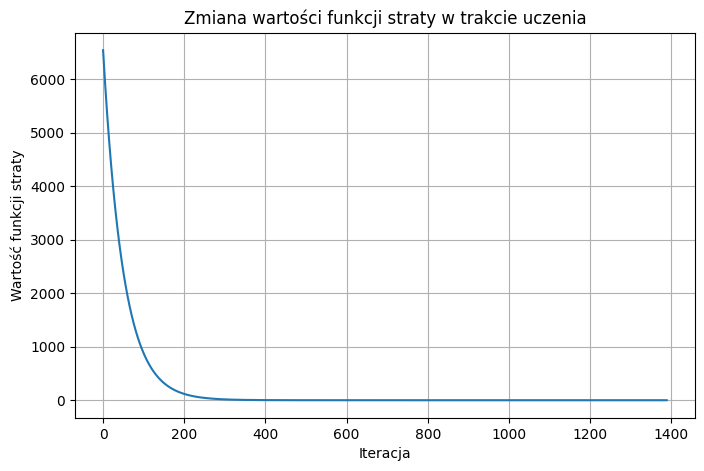

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(loss_history)
plt.xlabel("Iteracja")
plt.ylabel("Wartość funkcji straty")
plt.title("Zmiana wartości funkcji straty w trakcie uczenia")
plt.grid(True)
plt.show()

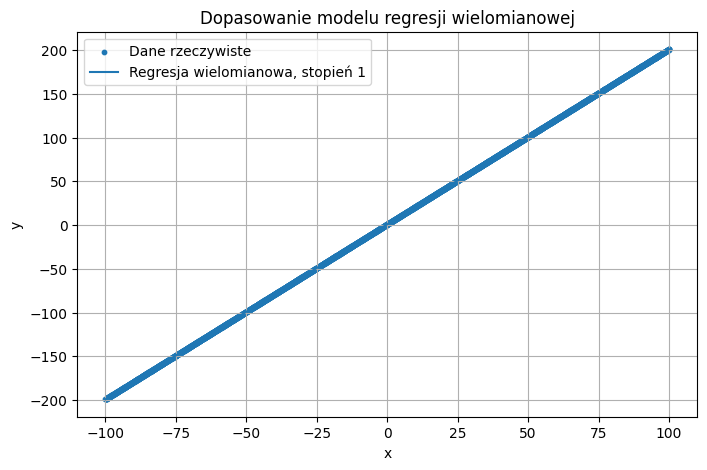

In [11]:
y_pred = predict(X, theta)

plt.figure(figsize=(8, 5))
plt.scatter(x, y, label="Dane rzeczywiste", s=10)

sorted_indices = np.argsort(x)
plt.plot(
    x[sorted_indices],
    y_pred[sorted_indices],
    label=f"Regresja wielomianowa, stopień {degree}"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Dopasowanie modelu regresji wielomianowej")
plt.legend()
plt.grid(True)
plt.show()